In [13]:
# final_analysis_bidm.py
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn optional - fallback to matplotlib styling
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    plt.style.use("ggplot")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [27]:
# ----------------------------
# SETTINGS / OUTPUT PATHS
# ----------------------------
INPUT_XLSX = "/content/BIDM_data.xlsx"
OUT_DIR = "/content/data/figures"
OUT_CSV = "AI_Readiness_StateScores_Enhanced.csv"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------
# 1) LOAD workbook (first sheet)
# ----------------------------
if not os.path.exists(INPUT_XLSX):
    raise FileNotFoundError(f"Input file not found: {INPUT_XLSX}. Place your BIDM_data.xlsx at that path.")

# read first sheet into dataframe
xls = pd.ExcelFile(INPUT_XLSX)
sheet_name = xls.sheet_names[0]
df = pd.read_excel(xls, sheet_name=sheet_name)
df.columns = [str(c).strip() for c in df.columns]

print(f"Loaded sheet '{sheet_name}' with shape {df.shape}")

Loaded sheet 'AIReadinessScore' with shape (36, 2)


In [18]:
# ----------------------------
# 2) Robustly detect State and Score columns
# ----------------------------
# Helper to find column matching any token
def find_column_by_tokens(cols, tokens):
    for t in tokens:
        for c in cols:
            if t in str(c).lower():
                return c
    return None

cols = df.columns.tolist()
state_tokens = ["state","ut","union territory","region","district"]
score_tokens = ["score","value","index","readiness","rating","score_","state_score","ai_score"]

state_col = find_column_by_tokens(cols, state_tokens)
score_col = find_column_by_tokens(cols, score_tokens)

# If not found, try looser heuristics: look for a string column with many unique values (likely state names)
if state_col is None:
    string_cols = [c for c in cols if df[c].dtype == object or df[c].dtype == 'string']
    for c in string_cols:
        nunique = df[c].nunique(dropna=True)
        if nunique >= 5 and nunique <= 40:  # typical # of states/UTs
            state_col = c
            print(f"Inferred state column as '{state_col}' by heuristics.")
            break

if score_col is None:
    # look for numeric columns with 'score-like' counts or with small range maybe
    numeric_cols_try = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    # prefer numeric columns with 'score' in name, else choose numeric column with moderate variance
    if numeric_cols_try:
        score_col = numeric_cols_try[0]
        print(f"No explicit 'score' column found — defaulting to first numeric column '{score_col}'.")
    else:
        raise ValueError("Couldn't detect a Score column automatically. Rename your score column to include 'score' or 'StateScore'.")

# rename to standard names
df = df.rename(columns={state_col: "State", score_col: "StateScore"})
print(f"Using State column: 'State' (from '{state_col}')")
print(f"Using Score column: 'StateScore' (from '{score_col}')")


Using State column: 'State' (from 'State')
Using Score column: 'StateScore' (from 'Score')


In [19]:
# ----------------------------
# 3) Convert numeric-looking columns to numeric safely and detect numeric indicators
# ----------------------------
df_proc = df.copy()
for c in df_proc.columns:
    # try to coerce numeric where possible (errors='ignore' keeps non-numeric as-is)
    df_proc[c] = pd.to_numeric(df_proc[c], errors='ignore')

numeric_cols = [c for c in df_proc.columns if pd.api.types.is_numeric_dtype(df_proc[c])]

# Exclude non-indicator numeric columns by name
exclude_names = set([
    "Rank","Cluster","BucketLabel","PC1","PC2","Is_UT","PerformanceColor","PerformanceBucket","Color"
])
numeric_cols = [c for c in numeric_cols if c not in exclude_names and c != "StateScore"]

print("\nDetected numeric indicator columns (used as features):")
print(numeric_cols)

# If no numeric indicator columns found, fall back to using StateScore only
if len(numeric_cols) == 0:
    numeric_cols = ["StateScore"]
    print("No numeric indicator columns detected — using only 'StateScore' as feature.")

# final features (include StateScore as a feature too)
feature_cols = ["StateScore"] + [c for c in numeric_cols if c != "StateScore"]
feature_cols = list(dict.fromkeys(feature_cols))  # unique, preserve order
print("\nFinal feature columns used for analysis:")
print(feature_cols)



Detected numeric indicator columns (used as features):
[]
No numeric indicator columns detected — using only 'StateScore' as feature.

Final feature columns used for analysis:
['StateScore']


In [20]:
# ----------------------------
# 4) Create buckets (Low/Medium/High) with slightly non-exact quantiles to avoid perfect separation
# ----------------------------
q_low = 0.30
q_high = 0.70
low_thr = df_proc["StateScore"].quantile(q_low)
high_thr = df_proc["StateScore"].quantile(q_high)

def assign_bucket(x):
    if pd.isna(x): return "Medium"
    if x <= low_thr: return "Low"
    elif x <= high_thr: return "Medium"
    else: return "High"

df_proc["PerformanceBucket"] = df_proc["StateScore"].apply(assign_bucket)
df_proc["PerformanceColor"] = df_proc["PerformanceBucket"].map({"Low":"red","Medium":"orange","High":"green"})
df_proc["Rank"] = df_proc["StateScore"].rank(method="min", ascending=False).astype("Int64")

print("\nBucket distribution:")
print(df_proc["PerformanceBucket"].value_counts())


Bucket distribution:
PerformanceBucket
Medium    14
Low       11
High      11
Name: count, dtype: int64


In [21]:
# ----------------------------
# 5) Add Region & Is_UT (basic mapping, extend as needed)
# ----------------------------
region_map = {
    # South
    "andhra pradesh":"South","telangana":"South","tamil nadu":"South","kerala":"South","karnataka":"South",
    "puducherry":"South","lakshadweep":"South",
    # West
    "maharashtra":"West","gujarat":"West","goa":"West","rajasthan":"West","madhya pradesh":"West","chhattisgarh":"West",
    # North
    "delhi":"North","haryana":"North","himachal":"North","jammu":"North","kashmir":"North","punjab":"North","uttar":"North","uttarakhand":"North","chandigarh":"North",
    # East
    "bihar":"East","jharkhand":"East","odisha":"East","west bengal":"East","sikkim":"East",
    # NorthEast
    "assam":"NorthEast","arunachal":"NorthEast","nagaland":"NorthEast","meghalaya":"NorthEast","manipur":"NorthEast","mizoram":"NorthEast","tripura":"NorthEast",
    # A&N
    "andaman":"NorthEast","nicobar":"NorthEast"
}
def map_region(s):
    if pd.isna(s): return "Unknown"
    s_lower = str(s).lower()
    for k,v in region_map.items():
        if k in s_lower:
            return v
    return "Other"

df_proc["Region"] = df_proc["State"].apply(map_region)
df_proc["Is_UT"] = df_proc["State"].apply(lambda x: 1 if any(t in str(x).lower() for t in ["puducherry","delhi","chandigarh","ladakh","lakshadweep","andaman","nicobar","daman","nagar"]) else 0)

# ----------------------------
# 6) Save enhanced CSV
# ----------------------------
df_proc.to_csv(OUT_CSV, index=False)
print(f"\nSaved enhanced CSV to: {OUT_CSV}")


Saved enhanced CSV to: AI_Readiness_StateScores_Enhanced.csv


In [24]:
# ----------------------------
# 7) VISUALS: correlation heatmap
# ----------------------------
# Prepare feature dataframe for visuals
feat_df = df_proc[feature_cols].copy()
feat_df = feat_df.fillna(feat_df.median())

corr = feat_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap — Numeric Indicators")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "correlation_heatmap.png"), dpi=150)
plt.close()
print("Saved correlation heatmap")

Saved correlation heatmap


In [28]:
# ----------------------------
# Visualization code (run after saving enhanced CSV)
# ----------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    plt.style.use("ggplot")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

ENHANCED_CSV = "/content/AI_Readiness_StateScores_Enhanced.csv"  # path to your saved CSV
OUT_DIR = "/content/data/figures"
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(ENHANCED_CSV):
    raise FileNotFoundError(f"Enhanced CSV not found at {ENHANCED_CSV}. Make sure you saved it before running visuals.")

# Load CSV
df = pd.read_csv(ENHANCED_CSV)
print("Loaded enhanced CSV with shape:", df.shape)

# Basic checks & fallback column names
if "State" not in df.columns:
    # try to find a likely state column
    possible_state = next((c for c in df.columns if "state" in c.lower() or "ut" in c.lower()), None)
    if possible_state:
        df = df.rename(columns={possible_state: "State"})
        print(f"Renamed '{possible_state}' -> 'State'")
    else:
        raise ValueError("No 'State' column found in CSV.")

if "StateScore" not in df.columns:
    possible_score = next((c for c in df.columns if "score" in c.lower() or "value" in c.lower()), None)
    if possible_score:
        df = df.rename(columns={possible_score: "StateScore"})
        print(f"Renamed '{possible_score}' -> 'StateScore'")
    else:
        raise ValueError("No 'StateScore' column found in CSV.")

# Create buckets if missing
if "PerformanceBucket" not in df.columns:
    q_low = df["StateScore"].quantile(0.30)
    q_high = df["StateScore"].quantile(0.70)
    def assign_bucket(x):
        if x <= q_low: return "Low"
        elif x <= q_high: return "Medium"
        else: return "High"
    df["PerformanceBucket"] = df["StateScore"].apply(assign_bucket)
    print("Created PerformanceBucket from quantiles.")

# Color map
color_map = {"High":"green","Medium":"orange","Low":"red"}
df["PerformanceColor"] = df["PerformanceBucket"].map(color_map).fillna("grey")

# Detect numeric indicator columns
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c not in ["Rank","Cluster","PC1","PC2"]]
# remove StateScore from indicators since we will keep it explicitly in features
indicator_cols = [c for c in numeric_cols if c != "StateScore"]

print("Numeric indicators detected (examples):", indicator_cols[:10])

# ---------- 1) Bucket counts bar plot ----------
plt.figure(figsize=(6,4))
order = ["High","Medium","Low"]
counts = df["PerformanceBucket"].value_counts().reindex(order).fillna(0)
bar_colors = [color_map.get(x,"grey") for x in counts.index]
plt.bar(counts.index, counts.values, color=bar_colors, edgecolor="k")
plt.title("States by Performance Bucket")
plt.ylabel("Count")
for i,v in enumerate(counts.values):
    plt.text(i, v + 0.02, int(v), ha='center')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "bucket_counts.png"), dpi=150)
plt.close()
print("Saved: bucket_counts.png")



Loaded enhanced CSV with shape: (36, 7)
Numeric indicators detected (examples): ['Is_UT']
Saved: bucket_counts.png


In [29]:
# ---------- 2) Correlation heatmap of numeric indicators ----------
# choose features for correlation: include StateScore + indicator_cols (if any)
corr_features = ["StateScore"] + indicator_cols
if len(corr_features) >= 2:
    corr_df = df[corr_features].copy().fillna(df[corr_features].median())
    corr = corr_df.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation Heatmap — Numeric Indicators")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "correlation_heatmap.png"), dpi=150)
    plt.close()
    print("Saved: correlation_heatmap.png")
else:
    print("Not enough numeric features to plot correlation heatmap.")


Saved: correlation_heatmap.png


In [30]:
# ---------- 3) PCA 2D map (State similarity) ----------
features_for_pca = corr_features
X = df[features_for_pca].fillna(df[features_for_pca].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = pcs[:,0], pcs[:,1]

plt.figure(figsize=(11,7))
for _, r in df.iterrows():
    plt.scatter(r["PC1"], r["PC2"], s=120, color=r["PerformanceColor"], edgecolor="k", alpha=0.9)
# label a few important points but not all (label top 5 and bottom 5 by StateScore)
top5 = df.nlargest(5, "StateScore")
bot5 = df.nsmallest(5, "StateScore")
for _, row in pd.concat([top5, bot5]).iterrows():
    plt.text(row["PC1"]+0.02, row["PC2"]+0.02, row["State"], fontsize=8)
plt.title("PCA 2D Map — State similarity")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_2d_map.png"), dpi=150)
plt.close()
print("Saved: pca_2d_map.png")


Saved: pca_2d_map.png


In [31]:
# ---------- 4) KMeans clustering on PCA space (k=3) ----------
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=120)
plt.title(f"KMeans Clusters (k={k}) on PCA")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "kmeans_pca_clusters.png"), dpi=150)
plt.close()
print("Saved: kmeans_pca_clusters.png")



Saved: kmeans_pca_clusters.png


In [32]:
# ---------- 5) Quadrant scatter with top 3 labelled per bucket ----------
mean_score = df["StateScore"].mean()
df["DeltaFromMean"] = df["StateScore"] - mean_score

# pick top 3 per bucket
topn = 3
top_rows = []
for bucket in ["High","Medium","Low"]:
    subset = df[df["PerformanceBucket"] == bucket].copy()
    subset_sorted = subset.sort_values("StateScore", ascending=False)
    topk = subset_sorted.head(topn)
    top_rows.append(topk)
top3_df = pd.concat(top_rows, ignore_index=True)

# save top3 csv
top3_csv = os.path.join(OUT_DIR, "top3_per_bucket.csv")
top3_df[["State","StateScore","PerformanceBucket","DeltaFromMean"]].to_csv(top3_csv, index=False)
print("Saved top3 per bucket CSV:", top3_csv)

# plot quadrant
plt.figure(figsize=(13,6))
ax = plt.gca()
# plot all points
ax.scatter(df["StateScore"], df["DeltaFromMean"], s=90, c=df["PerformanceBucket"].map(color_map), edgecolor='k', alpha=0.85)

# highlight and label top3
x_range = df["StateScore"].max() - df["StateScore"].min()
y_range = df["DeltaFromMean"].max() - df["DeltaFromMean"].min()
x_off = 0.03 * x_range
y_off = 0.03 * (y_range if y_range>0 else 1.0)

for _, r in top3_df.iterrows():
    ax.scatter(r["StateScore"], r["DeltaFromMean"], s=240, facecolor=color_map.get(r["PerformanceBucket"], "grey"),
               edgecolor='black', linewidth=1.2, zorder=5)
    ax.text(r["StateScore"] + x_off, r["DeltaFromMean"] + y_off, r["State"], fontsize=9, weight='bold', zorder=6)

# median vertical and mean horizontal
ax.axvline(df["StateScore"].median(), color='grey', linestyle='--', linewidth=1)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

ax.set_xlabel("StateScore", fontsize=12)
ax.set_ylabel("Score minus national mean", fontsize=12)
ax.set_title("Quadrant: State placement vs national mean (top 3 labelled per bucket)", fontsize=14)

# custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='High', markerfacecolor='green', markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Medium', markerfacecolor='orange', markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Low', markerfacecolor='red', markersize=8, markeredgecolor='k')
]
ax.legend(handles=legend_elements, title="Bucket", loc='upper left')

plt.tight_layout()
quad_png = os.path.join(OUT_DIR, "quadrant_top3.png")
plt.savefig(quad_png, dpi=150)
plt.close()
print("Saved: quadrant_top3.png")

# ---------- 6) Region boxplot (if Region available) ----------
if "Region" in df.columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x="Region", y="StateScore", data=df, palette='pastel')
    sns.stripplot(x='Region', y='StateScore', data=df, hue='PerformanceBucket',
                  dodge=False, marker='o', linewidth=0.5, palette=color_map, alpha=0.8)
    plt.title("AI Readiness (StateScore) by Region")
    plt.xticks(rotation=45)
    plt.legend(title='Bucket', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "region_boxplot.png"), dpi=150)
    plt.close()
    print("Saved: region_boxplot.png")
else:
    print("No 'Region' column found — skipping region boxplot.")

print("\nAll figures & CSV outputs saved to:", OUT_DIR)

Saved top3 per bucket CSV: /content/data/figures/top3_per_bucket.csv
Saved: quadrant_top3.png
Saved: region_boxplot.png

All figures & CSV outputs saved to: /content/data/figures


In [33]:
# ----------------------------
# Classification models + confusion matrices
# Append this after visuals. Requires sklearn installed.
# ----------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# ensure output dir exists
OUT_DIR = "/content/data/figures"
os.makedirs(OUT_DIR, exist_ok=True)

# Load enhanced CSV (if not in memory)
ENHANCED_CSV = "/content/AI_Readiness_StateScores_Enhanced.csv"
if os.path.exists(ENHANCED_CSV):
    df = pd.read_csv(ENHANCED_CSV)
else:
    # if df already exists in workspace (from prior cell), keep it
    try:
        df
    except NameError:
        raise FileNotFoundError(f"{ENHANCED_CSV} not found and 'df' not in memory.")

# Recreate or verify PerformanceBucket
if "PerformanceBucket" not in df.columns:
    q_low = df["StateScore"].quantile(0.30)
    q_high = df["StateScore"].quantile(0.70)
    def assign_bucket(x):
        if x <= q_low: return "Low"
        elif x <= q_high: return "Medium"
        else: return "High"
    df["PerformanceBucket"] = df["StateScore"].apply(assign_bucket)

# Build feature list: StateScore + indicator numeric cols (recompute if needed)
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
indicator_cols = [c for c in numeric_cols if c not in ["StateScore","Rank","Cluster","PC1","PC2","Is_UT"]]
feature_cols = ["StateScore"] + [c for c in indicator_cols if c != "StateScore"]

print("Using feature columns for classification:", feature_cols)



Using feature columns for classification: ['StateScore']


In [34]:
# Prepare X, y
X = df[feature_cols].fillna(df[feature_cols].median()).values
le = LabelEncoder()
y = le.fit_transform(df["PerformanceBucket"].astype(str))  # Low/Medium/High -> 0/1/2
class_names = le.classes_.tolist()
print("Class order:", class_names)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=42)

# Define models to evaluate
models = {
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto", random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}



Class order: ['High', 'Low', 'Medium']


In [35]:
# Use 5-fold stratified CV for each model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

summary_rows = []
for name, model in models.items():
    print(f"\n===== Model: {name} =====")
    # Cross-validation accuracy
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
    print("CV accuracy scores:", np.round(cv_scores, 3))
    print("Mean CV accuracy:", round(cv_scores.mean(), 3))

    # Fit on training set and evaluate on test set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Test accuracy:", round(acc, 3))

    creport = classification_report(y_test, y_pred, target_names=class_names, zero_division=0)
    print("\nClassification report:\n", creport)

    # store summary metrics per-class and overall
    precisions, recalls, f1s, supports = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
    for cls_idx, cls_name in enumerate(class_names):
        summary_rows.append({
            "model": name,
            "class": cls_name,
            "precision": round(float(precisions[cls_idx]), 3),
            "recall": round(float(recalls[cls_idx]), 3),
            "f1": round(float(f1s[cls_idx]), 3),
            "support": int(supports[cls_idx]),
            "test_accuracy": round(acc, 3),
            "cv_mean_accuracy": round(float(cv_scores.mean()), 3)
        })

    # Save classification report text file for reference
    rpt_path = os.path.join(OUT_DIR, f"classification_report_{name}.txt")
    with open(rpt_path, "w") as fh:
        fh.write(f"Model: {name}\n")
        fh.write(f"CV scores: {cv_scores.tolist()}\n")
        fh.write(f"Mean CV: {cv_scores.mean():.4f}\n\n")
        fh.write("Classification report (test set):\n")
        fh.write(creport)
    print("Saved report text to:", rpt_path)

    # Confusion matrix (plot + save)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} — Confusion Matrix (test)")
    cm_path = os.path.join(OUT_DIR, f"confusion_matrix_{name}.png")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=150)
    plt.close()
    print("Saved confusion matrix to:", cm_path)

# Save combined CSV summary
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "classification_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print("\nSaved classification summary to:", summary_csv)

# Also save a model comparison table (mean CV accuracy, test accuracy averaged across classes)
comp = summary_df.groupby("model").agg({
    "cv_mean_accuracy": "first",
    "test_accuracy": "first"
}).reset_index()
comp_csv = os.path.join(OUT_DIR, "model_comparison.csv")
comp.to_csv(comp_csv, index=False)
print("Saved model comparison to:", comp_csv)

print("\nClassification step completed. Check the figures and CSVs in:", OUT_DIR)


===== Model: RandomForest =====
CV accuracy scores: [0.875 1.    0.857 1.    0.857]
Mean CV accuracy: 0.918
Test accuracy: 0.778

Classification report:
               precision    recall  f1-score   support

        High       1.00      0.67      0.80         3
         Low       0.75      1.00      0.86         3
      Medium       0.67      0.67      0.67         3

    accuracy                           0.78         9
   macro avg       0.81      0.78      0.77         9
weighted avg       0.81      0.78      0.77         9

Saved report text to: /content/data/figures/classification_report_RandomForest.txt
Saved confusion matrix to: /content/data/figures/confusion_matrix_RandomForest.png

===== Model: LogisticRegression =====
CV accuracy scores: [0.875 1.    0.857 1.    0.714]
Mean CV accuracy: 0.889
Test accuracy: 0.889

Classification report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       0.75     

adjustText not available — falling back to heuristic label placement. Install with: pip install adjustText for better results.


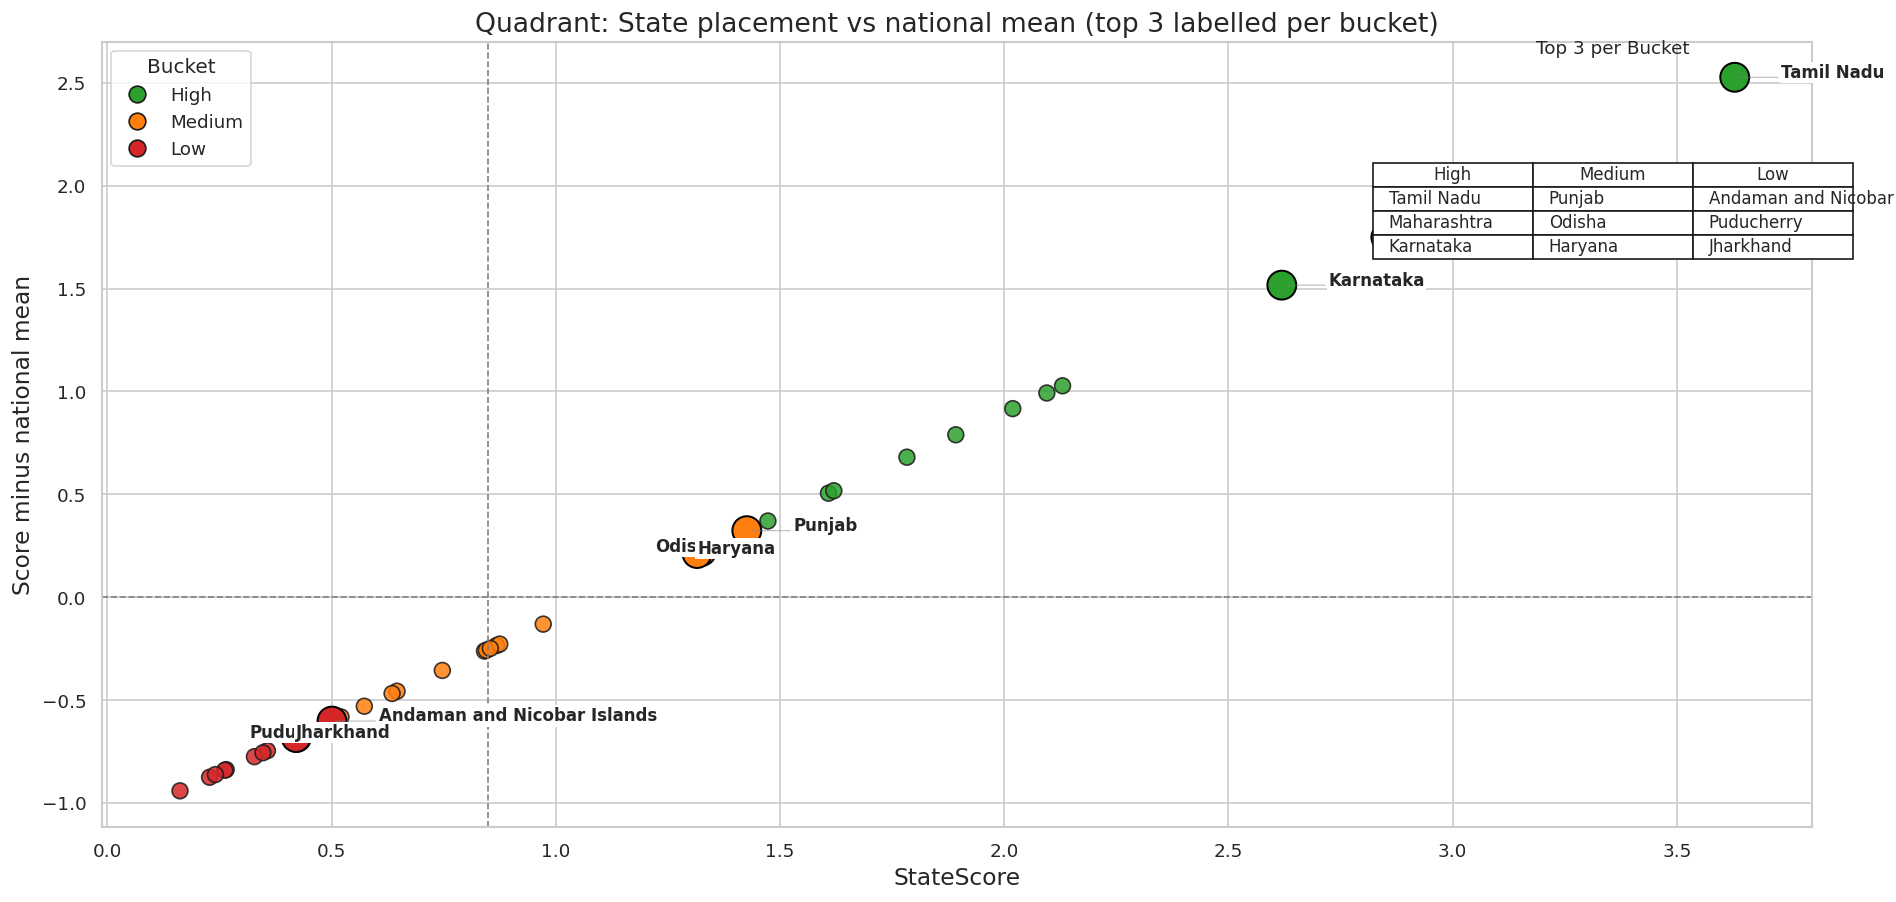

Saved improved quadrant plot to: /content/data/figures/quadrant_top3_improved.png


In [36]:
# improved_quadrant_labels.py
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.table import Table

# try to use seaborn styling if available
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    plt.style.use("ggplot")

# try import adjustText
use_adjusttext = True
try:
    from adjustText import adjust_text
except Exception:
    use_adjusttext = False
    print("adjustText not available — falling back to heuristic label placement. "
          "Install with: pip install adjustText for better results.")

IN_CSV = "/content/AI_Readiness_StateScores_Enhanced.csv"
OUT_DIR = "/content/data/figures"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(IN_CSV)
if "PerformanceBucket" not in df.columns:
    # simple quantile-based bucket (should exist already)
    q_low = df["StateScore"].quantile(0.30)
    q_high = df["StateScore"].quantile(0.70)
    df["PerformanceBucket"] = df["StateScore"].apply(lambda x: "Low" if x<=q_low else ("Medium" if x<=q_high else "High"))
df["DeltaFromMean"] = df["StateScore"] - df["StateScore"].mean()

color_map = {"High":"#2ca02c","Medium":"#ff7f0e","Low":"#d62728"}  # pleasant colors
df["PerformanceColor"] = df["PerformanceBucket"].map(color_map).fillna("#7f7f7f")

# pick top 3 per bucket
topn = 3
top_rows = []
for bucket in ["High","Medium","Low"]:
    subset = df[df["PerformanceBucket"]==bucket].nlargest(topn, "StateScore")
    top_rows.append(subset)
top3_df = pd.concat(top_rows, ignore_index=True)

# prepare plot
fig, ax = plt.subplots(figsize=(16,8))
# plot all points
ax.scatter(df["StateScore"], df["DeltaFromMean"], s=90, c=df["PerformanceColor"], edgecolor="k", alpha=0.85, zorder=1)

# emphasize top3: larger marker, black edge
ax.scatter(top3_df["StateScore"], top3_df["DeltaFromMean"], s=300, c=top3_df["PerformanceColor"],
           edgecolor="black", linewidth=1.2, zorder=3, marker='o')

# We will label only the top3 (clean) AND place a compact table inset listing the top3 names for each bucket.
texts = []
for i, row in top3_df.iterrows():
    x = row["StateScore"]
    y = row["DeltaFromMean"]
    lbl = str(row["State"])
    # create a text object slightly offset (adjustText will fine-tune it if available)
    t = ax.text(x, y, lbl, fontsize=10, weight='bold', zorder=4,
                bbox=dict(facecolor='white', edgecolor='none', pad=1))
    texts.append(t)

# if adjustText is available, use it to reduce overlaps (best option)
if use_adjusttext and len(texts) > 0:
    adjust_text(texts,
                only_move={'points':'y', 'texts':'y'},
                autoalign='xy',
                force_text=0.8,
                force_points=0.2,
                expand_text=(1.05,1.05),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))
else:
    # fallback: simple radial offsets to avoid exact overlap
    placed_boxes = []
    def collides(x0,y0,w,h, others):
        # axis coordinates assumed; naive box collision test
        for (x1,y1,w1,h1) in others:
            if (abs(x0-x1) < (w+w1)/2) and (abs(y0-y1) < (h+h1)/2):
                return True
        return False

    # simple heuristic: try offsets in 8 directions, accept first non-colliding
    x_range = df["StateScore"].max() - df["StateScore"].min()
    y_range = df["DeltaFromMean"].max() - df["DeltaFromMean"].min()
    x_step = 0.03 * (x_range if x_range!=0 else 1.0)
    y_step = 0.03 * (y_range if y_range!=0 else 1.0)
    offsets = [(x_step,0),( -x_step,0),(0,y_step),(0,-y_step),(x_step,y_step),(-x_step,y_step),(x_step,-y_step),(-x_step,-y_step)]
    new_texts = []
    for t, row in zip(texts, top3_df.itertuples()):
        x = row.StateScore
        y = row.DeltaFromMean
        placed = False
        for dx,dy in offsets:
            nx, ny = x+dx, y+dy
            # estimate box size in data coords (rough)
            w = 0.08 * (x_range if x_range!=0 else 1.0)
            h = 0.05 * (y_range if y_range!=0 else 1.0)
            if not collides(nx, ny, w, h, placed_boxes):
                # move text
                t.set_position((nx, ny))
                # draw small arrow from text to point
                ax.annotate('', xy=(x,y), xytext=(nx,ny), arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.6))
                placed_boxes.append((nx, ny, w, h))
                placed = True
                new_texts.append(t)
                break
        if not placed:
            # if no free slot, keep original (may overlap)
            new_texts.append(t)
    texts = new_texts

# Draw median vertical & mean horizontal lines
ax.axvline(df["StateScore"].median(), color='grey', linestyle='--', linewidth=1)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

ax.set_xlabel("StateScore", fontsize=14)
ax.set_ylabel("Score minus national mean", fontsize=14)
ax.set_title("Quadrant: State placement vs national mean (top 3 labelled per bucket)", fontsize=16)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='High', markerfacecolor=color_map["High"], markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Medium', markerfacecolor=color_map["Medium"], markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Low', markerfacecolor=color_map["Low"], markersize=10, markeredgecolor='k')
]
ax.legend(handles=legend_elements, title="Bucket", loc='upper left', fontsize=11)

# Create inset table listing top3 per bucket (so names are always visible)
# build a small dataframe for the table
table_df = pd.DataFrame()
for bucket in ["High","Medium","Low"]:
    subset = df[df["PerformanceBucket"]==bucket].nlargest(topn, "StateScore")
    names = list(subset["State"].astype(str).values)
    # pad to length 3
    while len(names) < topn:
        names.append("")
    table_df[bucket] = names

# draw table as an anchored axes
cell_width = 0.18
cell_height = 0.06
table_ax = fig.add_axes([0.72, 0.58, 0.25, 0.3])  # [left, bottom, width, height] in figure coords
table_ax.axis('off')
tbl = table_ax.table(cellText=table_df.values,
                     colLabels=table_df.columns,
                     cellLoc='left',
                     colLoc='center',
                     loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.2)
table_ax.set_title("Top 3 per Bucket", fontsize=11, pad=8)

# tighten and save
plt.tight_layout(rect=[0,0,1,0.96])
out_png = os.path.join(OUT_DIR, "quadrant_top3_improved.png")
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print("Saved improved quadrant plot to:", out_png)


adjustText not installed — falling back to heuristic placement. For best results: pip install adjustText


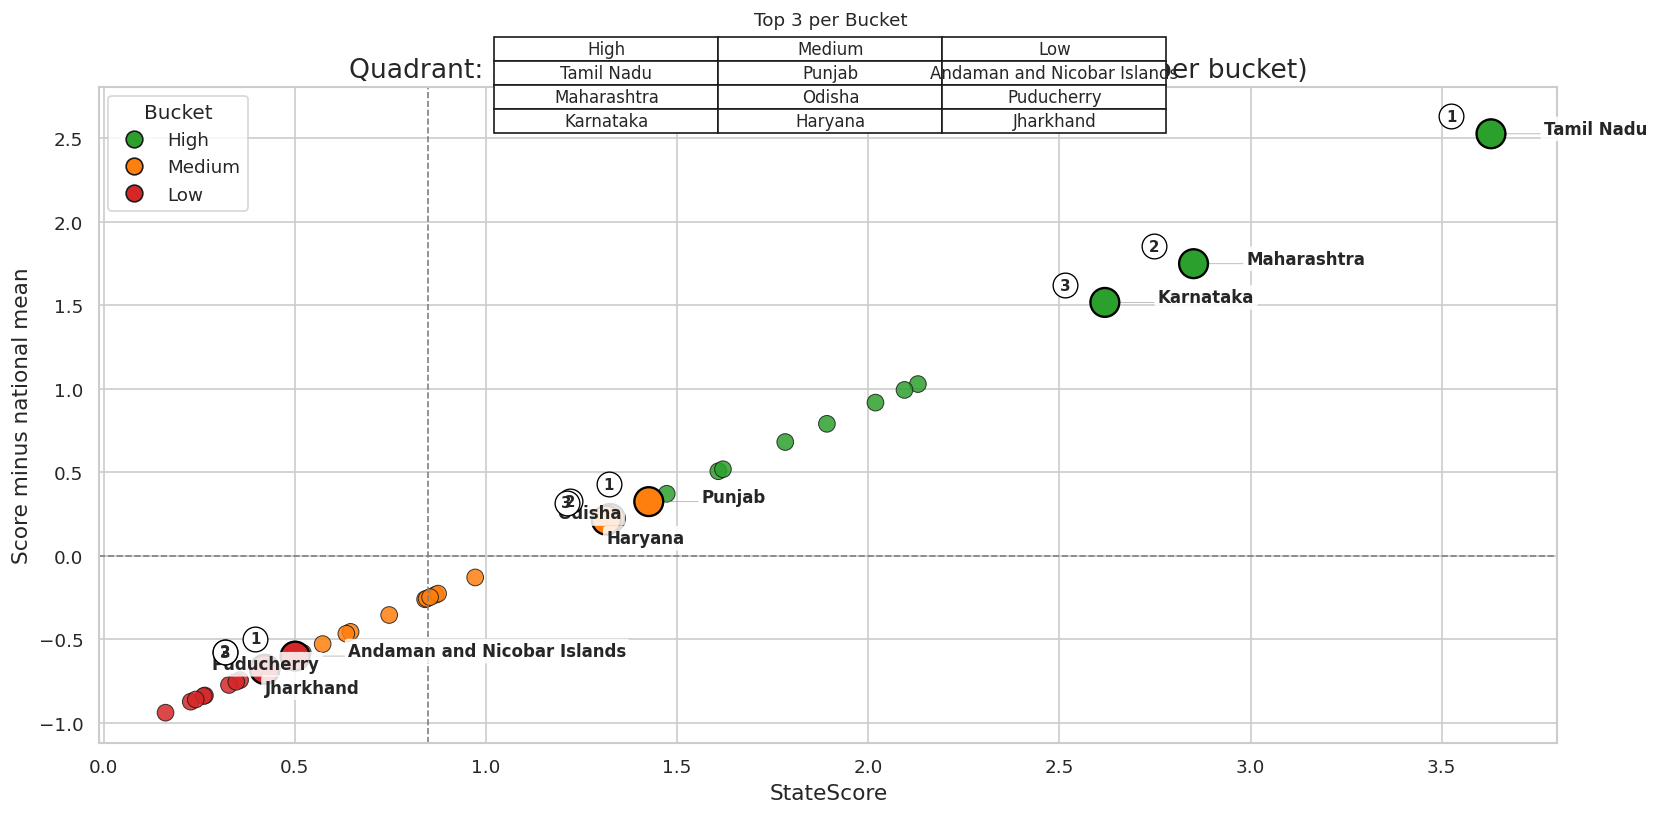

Saved improved quadrant plot to: /content/data/figures/quadrant_top3_final.png


In [39]:
# improved_quadrant_final.py
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try seaborn style
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    plt.style.use("ggplot")

# Try adjustText for best label placement
use_adjusttext = True
try:
    from adjustText import adjust_text
except Exception:
    use_adjusttext = False
    print("adjustText not installed — falling back to heuristic placement. For best results: pip install adjustText")

IN_CSV = "/content/AI_Readiness_StateScores_Enhanced.csv"
OUT_DIR = "/content/data/figures"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PNG = os.path.join(OUT_DIR, "quadrant_top3_final.png")

# --- load and prepare ---
df = pd.read_csv(IN_CSV)
if "State" not in df.columns:
    raise ValueError("CSV missing 'State' column")
if "StateScore" not in df.columns:
    raise ValueError("CSV missing 'StateScore' column")

# ensure bucket exists
if "PerformanceBucket" not in df.columns:
    q_low = df["StateScore"].quantile(0.30)
    q_high = df["StateScore"].quantile(0.70)
    df["PerformanceBucket"] = df["StateScore"].apply(lambda x: "Low" if x<=q_low else ("Medium" if x<=q_high else "High"))

# compute delta
df["DeltaFromMean"] = df["StateScore"] - df["StateScore"].mean()

# color map and ordering
bucket_order = ["High", "Medium", "Low"]
color_map = {"High":"#2ca02c","Medium":"#ff7f0e","Low":"#d62728"}
df["Color"] = df["PerformanceBucket"].map(color_map).fillna("#7f7f7f")

# get top 3 per bucket (by StateScore)
topn = 3
top3_list = []
for b in bucket_order:
    sub = df[df["PerformanceBucket"]==b].nlargest(topn, "StateScore")
    top3_list.append(sub)
top3_df = pd.concat(top3_list, ignore_index=True)

# plotting
fig, ax = plt.subplots(figsize=(14,7))

# plot all points (slightly translucent)
ax.scatter(df["StateScore"], df["DeltaFromMean"], s=100, c=df["Color"], edgecolor="k", alpha=0.85, linewidth=0.6, zorder=1)

# highlight top3 with larger marker and outline
ax.scatter(top3_df["StateScore"], top3_df["DeltaFromMean"], s=300, facecolors=top3_df["Color"],
           edgecolors="black", linewidth=1.4, zorder=4)

# numbered badges for top3: 1,2,3 (size and contrast)
# compute rank within bucket
badges = []
for b in bucket_order:
    subset = top3_df[top3_df["PerformanceBucket"]==b].sort_values("StateScore", ascending=False).reset_index(drop=True)
    for idx, row in subset.iterrows():
        rank = idx+1
        x, y = row["StateScore"], row["DeltaFromMean"]
        # draw a small filled circle for badge
        badge = ax.scatter([x - 0.03*(df["StateScore"].max()-df["StateScore"].min())],
                           [y + 0.03*(df["DeltaFromMean"].max()-df["DeltaFromMean"].min())],
                           s=220, c='white', edgecolor='black', linewidth=0.8, zorder=6)
        # place text over badge
        t = ax.text(x - 0.03*(df["StateScore"].max()-df["StateScore"].min()),
                    y + 0.03*(df["DeltaFromMean"].max()-df["DeltaFromMean"].min()),
                    str(rank), fontsize=9, fontweight='bold', ha='center', va='center', zorder=7)
        badges.append(t)

# create label objects (we will adjust these)
label_texts = []
for _, r in top3_df.iterrows():
    x, y = r["StateScore"], r["DeltaFromMean"]
    txt = ax.text(x, y, str(r["State"]), fontsize=10, fontweight='bold', zorder=5,
                  bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
    label_texts.append(txt)

# use adjustText if available, otherwise fallback heuristic
if use_adjusttext and len(label_texts)>0:
    adjust_text(label_texts,
                only_move={'texts':'y'},
                expand_text=(1.05,1.05),
                force_text=0.5,
                force_points=0.2,
                autoalign='y',
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))
else:
    # fallback: radial offset tries
    occupied = []
    x_range = df["StateScore"].max() - df["StateScore"].min() or 1.0
    y_range = df["DeltaFromMean"].max() - df["DeltaFromMean"].min() or 1.0
    offsets = [(0.04*x_range,0),( -0.04*x_range,0),(0,0.04*y_range),(0,-0.04*y_range),(0.04*x_range,0.04*y_range),(-0.04*x_range,0.04*y_range)]
    for txt, row in zip(label_texts, top3_df.itertuples()):
        x0, y0 = row.StateScore, row.DeltaFromMean
        placed=False
        for dx, dy in offsets:
            nx, ny = x0+dx, y0+dy
            # simple bounding box test
            collision=False
            for (xx,yy) in occupied:
                if abs(nx-xx) < 0.04*x_range and abs(ny-yy) < 0.04*y_range:
                    collision=True
                    break
            if not collision:
                txt.set_position((nx, ny))
                ax.annotate('', xy=(x0,y0), xytext=(nx,ny), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))
                occupied.append((nx, ny))
                placed=True
                break
        if not placed:
            # leave in place if cannot move
            occupied.append((x0, y0))

# median vertical and mean horizontal lines
ax.axvline(df["StateScore"].median(), color='grey', linestyle='--', linewidth=1)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

# axis labels & title
ax.set_xlabel("StateScore", fontsize=13)
ax.set_ylabel("Score minus national mean", fontsize=13)
ax.set_title("Quadrant: State placement vs national mean (Top-3 labeled per bucket)", fontsize=16)

# legend for buckets
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker='o', color='w', label='High', markerfacecolor=color_map['High'], markersize=10, markeredgecolor='k'),
    Line2D([0],[0], marker='o', color='w', label='Medium', markerfacecolor=color_map['Medium'], markersize=10, markeredgecolor='k'),
    Line2D([0],[0], marker='o', color='w', label='Low', markerfacecolor=color_map['Low'], markersize=10, markeredgecolor='k'),
]
ax.legend(handles=legend_elems, title="Bucket", loc='upper left')

# ---- centered table (top-center) ----
table_df = {}
for b in bucket_order:
    vals = list(top3_df[top3_df["PerformanceBucket"]==b]["State"])
    while len(vals) < topn:
        vals.append("")
    table_df[b] = vals
table_df = pd.DataFrame(table_df)

# Add centered table above axes (use figure coordinates)
table_ax = fig.add_axes([0.30, 0.82, 0.40, 0.12])  # [left, bottom, width, height] centered top
table_ax.axis('off')
tbl = table_ax.table(cellText=table_df.values, colLabels=table_df.columns, cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1,1.2)
table_ax.set_title("Top 3 per Bucket", fontsize=11, pad=6)

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight')
plt.show()

print("Saved improved quadrant plot to:", OUT_PNG)


adjustText not installed — using fallback label placement. Install with: pip install adjustText


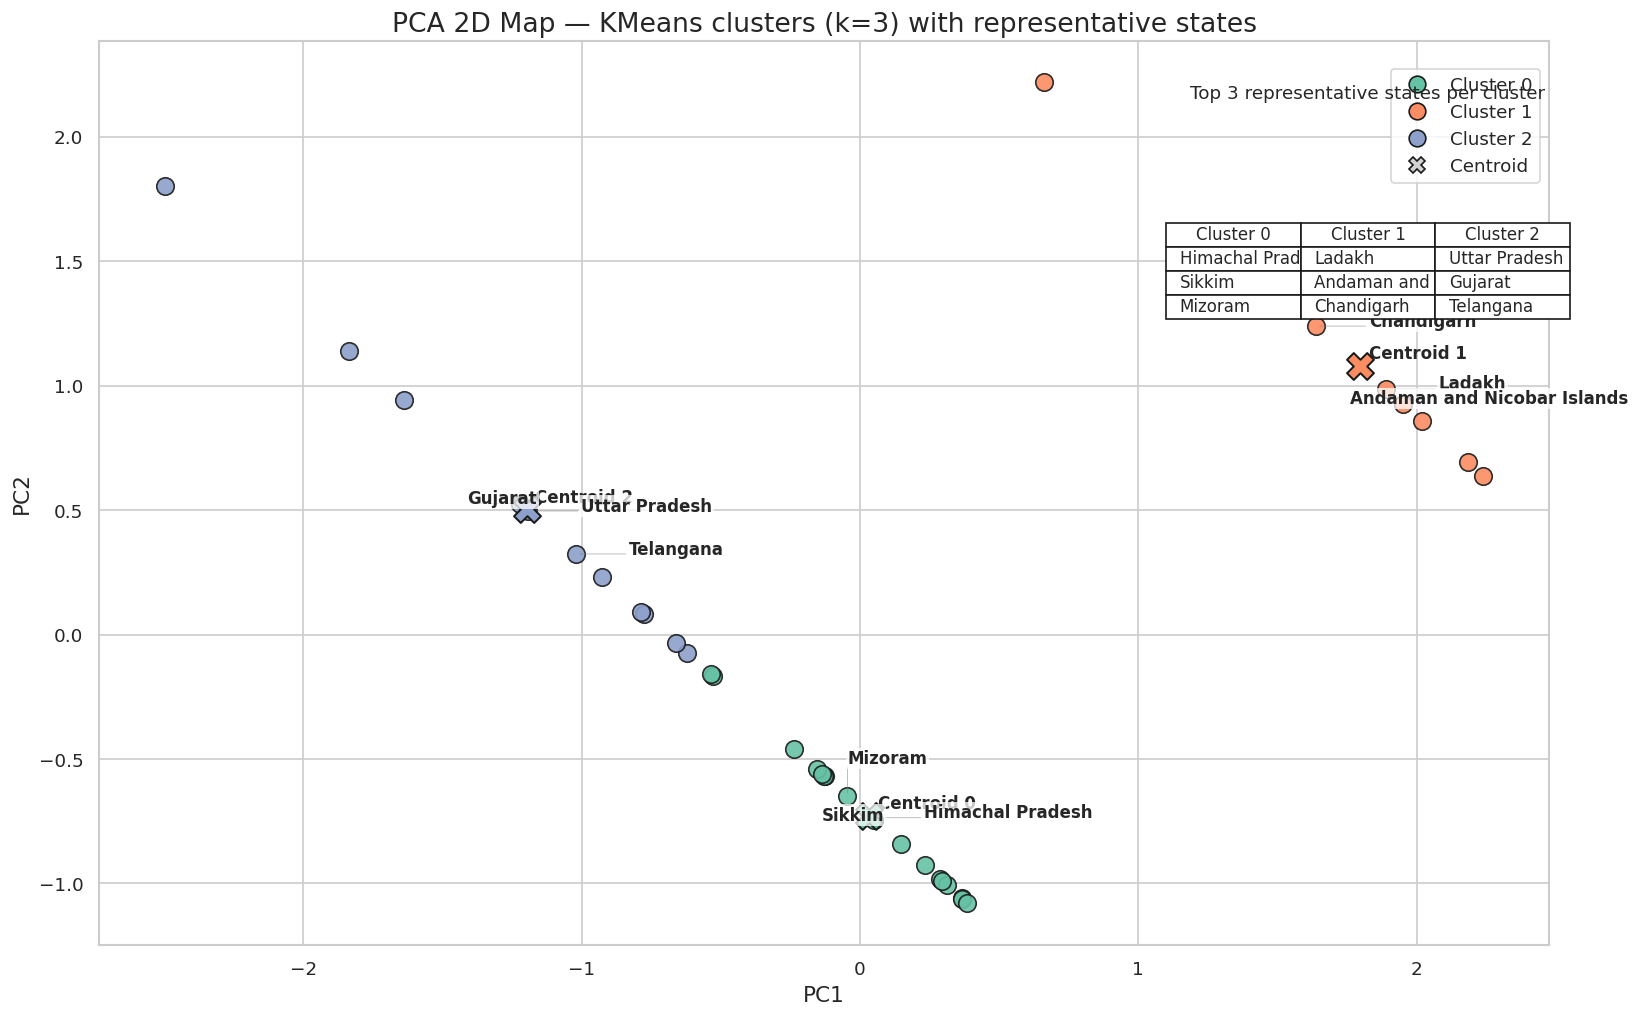

Saved improved PCA+KMeans plot to: /content/data/figures/pca_kmeans_improved.png


In [37]:
# improved_pca_kmeans_plot.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# styling
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    plt.style.use("ggplot")

# try to use adjustText for label deconfliction
use_adjusttext = True
try:
    from adjustText import adjust_text
except Exception:
    use_adjusttext = False
    print("adjustText not installed — using fallback label placement. Install with: pip install adjustText")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D

IN_CSV = "/content/AI_Readiness_StateScores_Enhanced.csv"
# try alternate path (common name from earlier)
if not os.path.exists(IN_CSV):
    IN_CSV = "/content/AI_Readiness_StateScores_Enhanced.csv"

OUT_DIR = "/content/data/figures"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PNG = os.path.join(OUT_DIR, "pca_kmeans_improved.png")

# load data
df = pd.read_csv(IN_CSV)
# sanity checks
if "State" not in df.columns:
    # attempt to find state-like column
    candidates = [c for c in df.columns if "state" in c.lower() or "ut" in c.lower()]
    if candidates:
        df = df.rename(columns={candidates[0]:"State"})
    else:
        raise ValueError("No 'State' column found in CSV.")
if "StateScore" not in df.columns:
    candidates = [c for c in df.columns if "score" in c.lower() or "value" in c.lower()]
    if candidates:
        df = df.rename(columns={candidates[0]:"StateScore"})
    else:
        raise ValueError("No 'StateScore' column found in CSV.")

# features: numeric indicators (include StateScore)
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
feature_cols = ["StateScore"] + [c for c in numeric_cols if c != "StateScore" and c not in ["Rank","Cluster","PC1","PC2"]]
feature_cols = list(dict.fromkeys(feature_cols))  # unique preserve order

# if too few features, fallback to StateScore only
if len(feature_cols) == 0:
    feature_cols = ["StateScore"]

X = df[feature_cols].fillna(df[feature_cols].median())

# PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = pcs[:,0], pcs[:,1]

# KMeans (k=3). You can change k as needed.
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_
# transform centroids to PCA space (centroids computed on scaled features)
centroids_pca = pca.transform(centroids)

# color palette (pleasant)
cluster_colors = sns.color_palette("Set2", n_colors=k)
cluster_cmap = {i: cluster_colors[i] for i in range(k)}

# pick representative top-3 states for each cluster:
# method: states closest to cluster centroid in PCA-space (good representatives)
topn = 3
rep_rows = []
for cl in range(k):
    sub = df[df["Cluster"] == cl].copy()
    if sub.shape[0] == 0:
        continue
    # compute euclidean distance in PCA space to centroid
    cx, cy = centroids_pca[cl]
    sub["dist_to_centroid"] = np.sqrt((sub["PC1"]-cx)**2 + (sub["PC2"]-cy)**2)
    sub_sorted = sub.sort_values("dist_to_centroid")
    rep = sub_sorted.head(topn)
    rep_rows.append(rep)
rep_df = pd.concat(rep_rows, ignore_index=True) if rep_rows else pd.DataFrame(columns=df.columns)

# Start plotting
fig, ax = plt.subplots(figsize=(14,9))

# plot points by cluster
for cl in range(k):
    tmp = df[df["Cluster"]==cl]
    ax.scatter(tmp["PC1"], tmp["PC2"], s=110, color=cluster_cmap[cl], edgecolor="k", alpha=0.9, label=f"Cluster {cl}")

# plot centroids
for cl in range(k):
    cx, cy = centroids_pca[cl]
    ax.scatter(cx, cy, s=260, marker="X", color=cluster_cmap[cl], edgecolor="k", linewidth=1.2, zorder=5)
    ax.text(cx+0.03, cy+0.03, f"Centroid {cl}", fontsize=10, weight="bold", zorder=6)

# label representative states (rep_df)
texts = []
for _, row in rep_df.iterrows():
    x, y = row["PC1"], row["PC2"]
    txt = ax.text(x, y, row["State"], fontsize=10, weight='bold', zorder=6,
                  bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1))
    texts.append(txt)
    # draw a subtle line from label to point (in case label moves)
    ax.plot([x, x], [y, y], alpha=0)  # placeholder if adjustText moves text

# use adjustText if available
if use_adjusttext and len(texts) > 0:
    adjust_text(texts,
                only_move={'points':'y','texts':'y'},
                expand_text=(1.02,1.04),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))
else:
    # fallback: attempt simple radial offset for each text to minimize collisions
    placed_boxes = []
    def collides(x0,y0,w,h, others):
        for (x1,y1,w1,h1) in others:
            if (abs(x0-x1) < (w+w1)/2) and (abs(y0-y1) < (h+h1)/2):
                return True
        return False
    x_range = df["PC1"].max() - df["PC1"].min() or 1.0
    y_range = df["PC2"].max() - df["PC2"].min() or 1.0
    offsets = [(0.04*x_range,0),( -0.04*x_range,0),(0,0.04*y_range),(0,-0.04*y_range),
               (0.04*x_range,0.04*y_range),(-0.04*x_range,0.04*y_range),(0.04*x_range,-0.04*y_range),(-0.04*x_range,-0.04*y_range)]
    for t, row in zip(texts, rep_df.itertuples()):
        x = row.PC1; y = row.PC2
        placed=False
        for dx,dy in offsets:
            nx, ny = x+dx, y+dy
            w = 0.06*x_range; h = 0.04*y_range
            if not collides(nx, ny, w, h, placed_boxes):
                t.set_position((nx, ny))
                ax.annotate('', xy=(x,y), xytext=(nx,ny), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))
                placed_boxes.append((nx, ny, w, h))
                placed=True
                break
        if not placed:
            # keep original
            placed_boxes.append((x,y,0.06*x_range,0.04*y_range))

# aesthetic lines/grid
ax.set_xlabel("PC1", fontsize=13)
ax.set_ylabel("PC2", fontsize=13)
ax.set_title(f"PCA 2D Map — KMeans clusters (k={k}) with representative states", fontsize=16)

# legend and tidy
legend_elements = [Line2D([0], [0], marker='o', color='w',
                         label=f"Cluster {i}", markerfacecolor=cluster_cmap[i], markeredgecolor='k', markersize=10)
                   for i in range(k)]
# add centroid marker legend
legend_elements.append(Line2D([0], [0], marker='X', color='w', label='Centroid', markerfacecolor='lightgray', markeredgecolor='k', markersize=10))
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 0.98))

# inset table with top-3 per cluster (by closeness)
table_df = {}
for cl in range(k):
    if cl in rep_df["Cluster"].values:
        names = list(rep_df[rep_df["Cluster"]==cl]["State"])
    else:
        names = []
    while len(names) < topn:
        names.append("")
    table_df[f"Cluster {cl}"] = names
table_df = pd.DataFrame(table_df)

# draw a small axes for the table
table_ax = fig.add_axes([0.70, 0.55, 0.24, 0.30])  # [left, bottom, width, height]
table_ax.axis('off')
tbl = table_ax.table(cellText=table_df.values, colLabels=table_df.columns, cellLoc='left', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1,1.2)
table_ax.set_title("Top 3 representative states per cluster", fontsize=11)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight')
plt.show()

print("Saved improved PCA+KMeans plot to:", OUT_PNG)


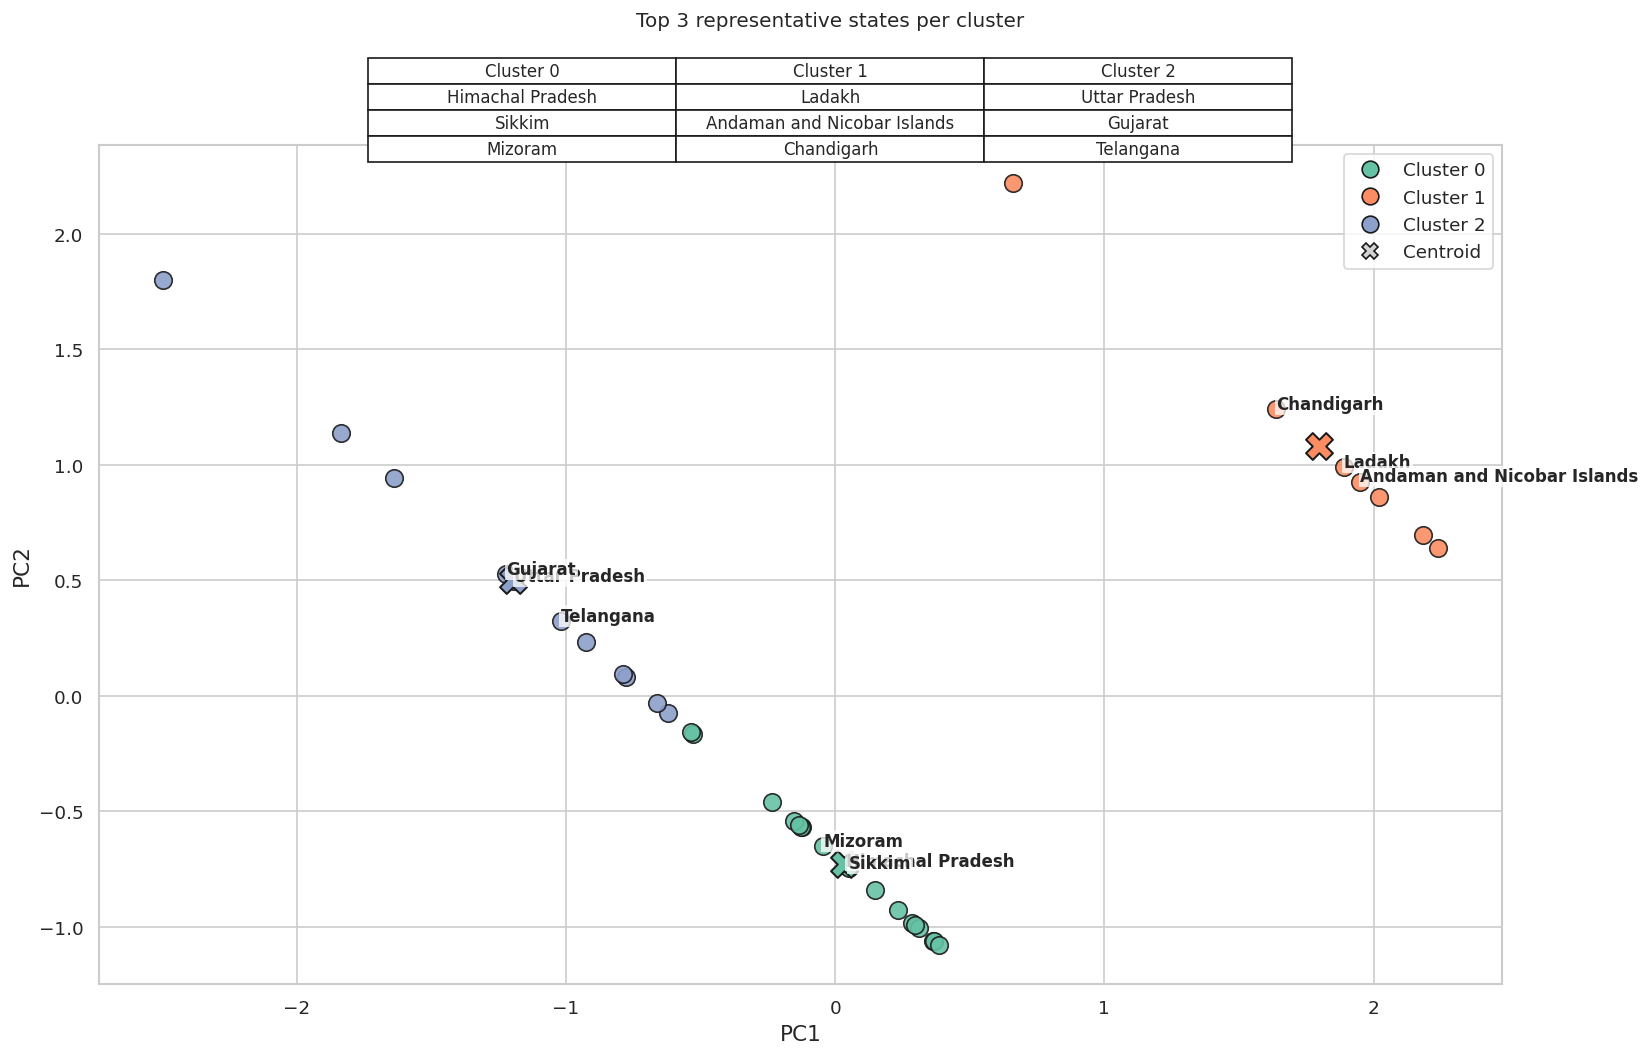

Saved improved PCA+KMeans plot to: /content/data/figures/pca_kmeans_improved.png


In [38]:
# -------------------------------
# Improved PCA + KMeans Plot (Clean Table Centered, No Centroid Labels)
# -------------------------------

fig, ax = plt.subplots(figsize=(14, 9))

# Plot cluster points
for cl in range(k):
    tmp = df[df["Cluster"] == cl]
    ax.scatter(
        tmp["PC1"], tmp["PC2"],
        s=110,
        color=cluster_cmap[cl],
        edgecolor="k",
        alpha=0.9,
        label=f"Cluster {cl}"
    )

# Plot centroids (marker only, no label)
for cl in range(k):
    cx, cy = centroids_pca[cl]
    ax.scatter(cx, cy, s=260, marker="X", color=cluster_cmap[cl],
               edgecolor="k", linewidth=1.2, zorder=5)

# Label representative states (the top 3 per cluster)
texts = []
for _, row in rep_df.iterrows():
    x, y = row["PC1"], row["PC2"]
    t = ax.text(
        x, y, row["State"],
        fontsize=10,
        weight="bold",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1),
        zorder=6
    )
    texts.append(t)

# Adjust labels to avoid overlap
if use_adjusttext and len(texts) > 0:
    adjust_text(
        texts,
        only_move={'texts':'y'},
        expand_text=(1.03, 1.03),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6)
    )

# Axis labels & title
ax.set_xlabel("PC1", fontsize=13)
ax.set_ylabel("PC2", fontsize=13)
ax.set_title("PCA 2D Map — KMeans clusters (k=3) with representative states", fontsize=16)

# Legend (clusters + centroid marker)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f"Cluster {i}",
           markerfacecolor=cluster_cmap[i], markeredgecolor='k', markersize=10)
    for i in range(k)
]
legend_elements.append(
    Line2D([0], [0], marker='X', color='w', label='Centroid',
           markerfacecolor="lightgray", markeredgecolor='k', markersize=10)
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.0, 1.0))

# -------------------------
# Centered Table at Top
# -------------------------

# Build table content (top 3 per cluster)
table_df = {}
for cl in range(k):
    names = list(rep_df[rep_df["Cluster"] == cl]["State"])
    # pad if fewer than 3 states are available
    while len(names) < topn:
        names.append("")
    table_df[f"Cluster {cl}"] = names

table_df = pd.DataFrame(table_df)

# Add centered inset table
table_ax = fig.add_axes([0.25, 0.82, 0.50, 0.13])  # center top
table_ax.axis("off")
tbl = table_ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 1.3)
table_ax.set_title("Top 3 representative states per cluster", fontsize=12, pad=8)

# Save high-res figure
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved improved PCA+KMeans plot to:", OUT_PNG)


In [40]:
recommendations = [
    "Prioritise digital infrastructure upgrades (fiber, broadband, mobile coverage) in low-readiness states to lift baseline connectivity.",
    "Accelerate digital-skills and AI-literacy programs in medium-readiness states to help them transition into the high-performance tier.",
    "Expand and replicate AI innovation hubs in high-readiness states to drive national-level spillover effects and ecosystem growth.",
    "Modernise state data systems (open-data portals, unified e-services, interoperable governance platforms) to unlock scalable AI use cases.",
    "Adopt a tiered policy framework (High–Medium–Low) so interventions are customised to each state’s actual readiness and capability."
]

for i, r in enumerate(recommendations, 1):
    print(f"{i}. {r}")


1. Prioritise digital infrastructure upgrades (fiber, broadband, mobile coverage) in low-readiness states to lift baseline connectivity.
2. Accelerate digital-skills and AI-literacy programs in medium-readiness states to help them transition into the high-performance tier.
3. Expand and replicate AI innovation hubs in high-readiness states to drive national-level spillover effects and ecosystem growth.
4. Modernise state data systems (open-data portals, unified e-services, interoperable governance platforms) to unlock scalable AI use cases.
5. Adopt a tiered policy framework (High–Medium–Low) so interventions are customised to each state’s actual readiness and capability.
